<a href="https://colab.research.google.com/github/mihirmitra11-sys/AstroRestore-UNet/blob/main/AstroRestore_Deep_Learning_for_Low_SNR_Signal_Recovery_in_Galactic_Imagery.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

def simulate_telescope_view(image, sigma=1.5, noise_level=0.05):
    """
    Simulates atmospheric blur and photon noise.
    image: normalized numpy array (0 to 1)
    """
    # 1. Apply Gaussian Blur (The PSF)
    blurred = gaussian_filter(image, sigma=sigma)

    # 2. Add Poisson-like Noise
    # Scaling up to simulate photon counts, adding noise, then scaling back
    vals = len(np.unique(blurred))
    vals = 2 ** np.ceil(np.log2(vals))
    noisy = np.random.poisson(blurred * vals) / float(vals)

    return np.clip(noisy, 0, 1)

# Usage Example:
# clean_img = your_dataset_image / 255.0
# dirty_img = simulate_telescope_view(clean_img)

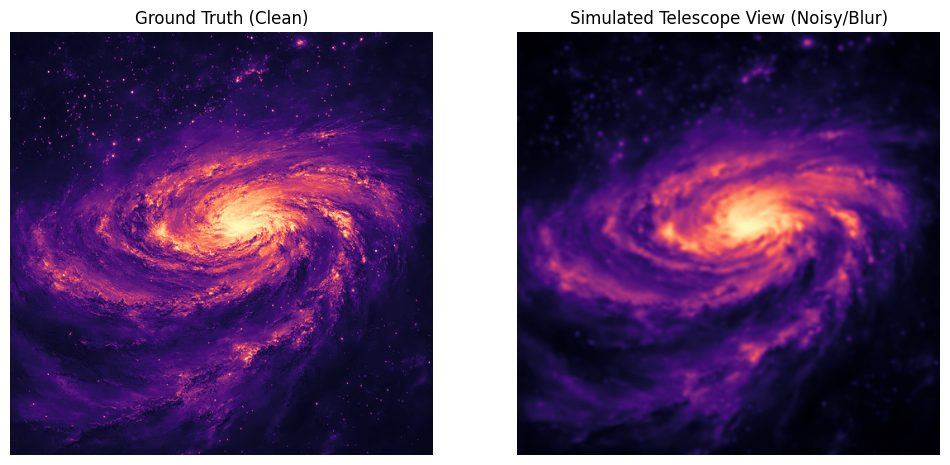

In [2]:
import requests
from PIL import Image
from io import BytesIO

# 1. Download the image from your GitHub
url = "https://raw.githubusercontent.com/mihirmitra11-sys/Galaxy-Morphology-CNN-Classifier/main/galactic-spiral-beauty-stockcake.webp"
response = requests.get(url)
img = Image.open(BytesIO(response.content)).convert('L') # Convert to Grayscale (typical for science data)
img = np.array(img) / 255.0 # Normalize to 0-1

# 2. Run the function we just defined
dirty_img = simulate_telescope_view(img, sigma=2.0, noise_level=0.08)

# 3. Plot the results side-by-side
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Ground Truth (Clean)")
plt.imshow(img, cmap='magma')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Simulated Telescope View (Noisy/Blur)")
plt.imshow(dirty_img, cmap='magma')
plt.axis('off')

plt.show()

In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_unet(input_shape=(256, 256, 1)):
    inputs = layers.Input(input_shape)

    # Encoder (Downsampling)
    c1 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    c2 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(p1)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    # Bottleneck
    b = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(p2)

    # Decoder (Upsampling)
    u1 = layers.UpSampling2D((2, 2))(b)
    # Skip Connection
    u1 = layers.Concatenate()([u1, c2])
    c3 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(u1)

    u2 = layers.UpSampling2D((2, 2))(c3)
    # Skip Connection
    u2 = layers.Concatenate()([u2, c1])
    c4 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(u2)

    # Output Layer
    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(c4)

    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='mse') # Mean Squared Error works best for denoising
    return model

# Initialize the model
unet_model = build_unet(input_shape=(img.shape[0], img.shape[1], 1))
unet_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 512, 512,  │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 256, 256,  │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 128, 128,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 256, 256,  │          0 │ conv2d_2[0][0]    │
│ (UpSampling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 256, 256,  │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 192)              │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 256, 256,  │    110,656 │ concatenate[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 512, 512,  │          0 │ conv2d_3[0][0]    │
│ (UpSampling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 512, 512,  │          0 │ up_sampling2d_1[… │
│ (Concatenate)       │ 96)               │            │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 512, 512,  │     27,680 │ concatenate_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 512, 512,  │         33 │ conv2d_4[0][0]    │
│                     │ 1)                │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 231,041 (902.50 KB)

 Trainable params: 231,041 (902.50 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
def cosmic_data_generator(clean_img, batch_size=4):
    while True:
        x_batch = []
        y_batch = []

        for _ in range(batch_size):
            # 1. Random Augmentation (Rotation/Flip)
            k = np.random.randint(0, 4)
            augmented = np.rot90(clean_img, k)
            if np.random.random() > 0.5:
                augmented = np.fliplr(augmented)

            # 2. Randomize the "Corruption" levels
            # Sometimes the telescope is blurrier, sometimes the noise is worse
            s = np.random.uniform(0.5, 2.5)
            noisy_img = simulate_telescope_view(augmented, sigma=s)

            # 3. Add Channel Dimension (Required for Keras)
            x_batch.append(noisy_img.reshape(512, 512, 1))
            y_batch.append(augmented.reshape(512, 512, 1))

        yield np.array(x_batch), np.array(y_batch)

# Create the generator instance
train_gen = cosmic_data_generator(img, batch_size=4)

In [5]:
# Train the model
history = unet_model.fit(
    train_gen,
    steps_per_epoch=20, # How many batches per 'round'
    epochs=15,
    verbose=1
)

Epoch 1/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 214s 11s/step - loss: 0.0626
Epoch 2/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 198s 10s/step - loss: 0.0097
Epoch 3/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 201s 10s/step - loss: 0.0068
Epoch 4/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 209s 10s/step - loss: 0.0063
Epoch 5/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 198s 10s/step - loss: 0.0048
Epoch 6/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 193s 10s/step - loss: 0.0027
Epoch 7/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 213s 11s/step - loss: 0.0022
Epoch 8/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 202s 10s/step - loss: 0.0020
Epoch 9/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 197s 10s/step - loss: 0.0020
Epoch 10/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 212s 11s/step - loss: 0.0019
Epoch 11/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 205s 10s/step - loss: 0.0019
Epoch 12/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 204s 10s/step - loss: 0.0017
Epoch 13/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 229s 11s/step - loss: 0.0018
Epoch 14/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 203s 10s/step - loss: 0.0016
Epoch 15/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 201s 10s/step - lo

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


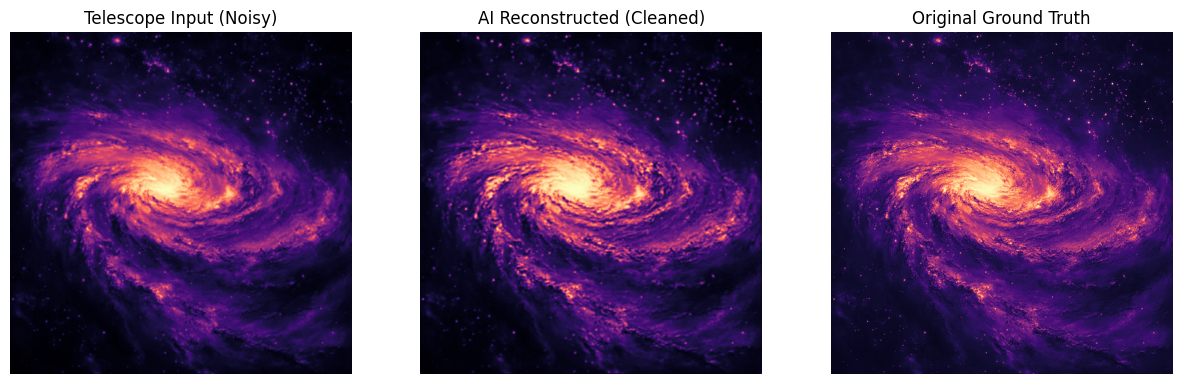

In [6]:
# 1. Generate a fresh test sample
test_x, test_y = next(train_gen)

# 2. Let the AI predict/clean the image
predicted_clean = unet_model.predict(test_x)

# 3. Plotting
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.title("Telescope Input (Noisy)")
plt.imshow(test_x[0].reshape(512, 512), cmap='magma')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("AI Reconstructed (Cleaned)")
plt.imshow(predicted_clean[0].reshape(512, 512), cmap='magma')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Original Ground Truth")
plt.imshow(test_y[0].reshape(512, 512), cmap='magma')
plt.axis('off')

plt.show()